# Linear Regression

## What linear regression does

Linear regression is one of the most fundamental tools in data analysis. The idea is simple: we draw the best possible straight line (or flat plane, if we have multiple predictors) through our data, and use that line to predict an output.

For example, if we want to predict sales based on TV advertising spending, we find the line that minimizes the total prediction error across all our data points. Once we have that line, we can plug in any TV budget and get a predicted sales figure.

When we have only one predictor, this is called **simple linear regression**. When we have multiple predictors (like TV, radio, and newspaper spending), it's called **multiple linear regression** — the math extends in more dimensions.

### Why would we use this instead of just looking at the data?

A few reasons:

- It lets us **quantify** the relationship. Not just "more TV spending seems to lead to more sales," but "each additional $1,000 spent on TV is associated with about 47 more units sold."
- It lets us make **predictions** for values we haven't observed.
- It gives us tools to assess whether a relationship is real or just noise.
- With multiple predictors, it helps us understand each predictor's **independent contribution** to the outcome, holding the others constant.

### What the coefficients mean

The coefficients are the slope values — one for each predictor. The coefficient for TV advertising tells you how much we expect sales to change for each one-unit increase in TV spending, *holding everything else constant*.

The intercept is the predicted value when all predictors are zero (which may or may not be a meaningful scenario, depending on the problem).

### Residuals and RSS

A **residual** is the difference between the actual observed value and the value our model predicted. If the model says sales should be 15 units but the actual value was 18, the residual is 3.

The **Residual Sum of Squares (RSS)** adds up all those squared residuals across every observation. We square them so that positive and negative errors don't cancel each other out, and so we penalize large errors more heavily than small ones.

Linear regression finds the coefficients that minimize the RSS. This is also called the **least squares** approach.

### What R-squared means

R-squared (written as R²) tells you what fraction of the variation in your outcome variable is explained by your model. It always falls between 0 and 1.

- R² = 0 means the model explains none of the variation in the outcome — it's no better than just guessing the average every time.
- R² = 1 means the model explains all of the variation — a perfect fit (which almost never happens in practice, and might indicate overfitting).
- R² = 0.7 means the model accounts for 70% of the variability in the outcome; the other 30% is due to factors not captured by the model.

R² is unit-free, which makes it easier to compare across different datasets than the raw RSS.

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
# In this notebook we'll use seaborn and statsmodels in addition to sklearn, to see some of the features those libraries offer
import pandas as pd
import numpy as np
import matplotlib.axis as axis
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d
import seaborn as sns

from sklearn.preprocessing import scale
import sklearn.linear_model as skl_lm
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set(font_scale=1.25)
plt.style.use('seaborn-v0_8-whitegrid')

## Advertising Data

Our first example will use advertising data, which tracks sales (in units) as a function of TV, radio, and newspaper advertising spending (in $).

In [3]:
url1 = 'https://raw.githubusercontent.com/dsahota-applied-data-analysis/data/main/Advertising.csv'
advertising = pd.read_csv(url1, usecols=[1,2,3,4])
advertising.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [4]:
advertising.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9



### Simple Linear Regression

For Simple Linear Regression, we will examine the effect of TV advertising on sales.

First, we can use sns.regplot to get a quick look at the data and whether a least squares fit line even makes sense when considering sales as a function of TV advertising. 

<Axes: xlabel='TV', ylabel='sales'>

(-10.0, 310.0)

(0.0, 28.27)

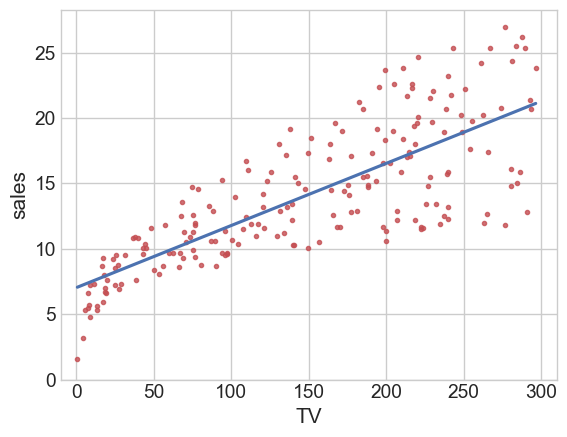

In [5]:
sns.regplot(x = advertising.TV, y = advertising.sales, order=1, ci=None, scatter_kws={'color':'r', 's':9})
plt.xlim(-10,310)
plt.ylim(ymin=0)

#### Try it yourself: adjusting the regression line

The slider below lets you manually adjust the slope and intercept of the line. Watch how the RSS changes as you move away from the optimal values. Notice that the RSS curve on the right has a clear minimum — that's exactly the point the least squares algorithm finds automatically.

In [6]:
import ipywidgets as widgets
from ipywidgets import interact

# Interactive exploration: manually adjust slope and intercept to see how RSS changes
@interact(
    intercept=widgets.FloatSlider(min=0, max=20, step=0.5, value=7.0, description='Intercept'),
    slope=widgets.FloatSlider(min=0, max=0.1, step=0.001, value=0.047, description='Slope', readout_format='.3f')
)
def plot_regression_line(intercept, slope):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Left: scatter with the line
    ax = axes[0]
    ax.scatter(advertising.TV, advertising.sales, color='red', s=10, alpha=0.6)
    x_range = np.linspace(advertising.TV.min(), advertising.TV.max(), 200)
    ax.plot(x_range, intercept + slope * x_range, color='blue', linewidth=2)
    ax.set_xlabel('TV Advertising Budget', fontsize=13)
    ax.set_ylabel('Sales', fontsize=13)
    ax.set_title('Regression Line', fontsize=14)

    # Right: RSS vs slope (holding intercept fixed) to show the minimum
    slopes = np.linspace(0, 0.1, 200)
    rss_vals = [((advertising.sales - (intercept + s * advertising.TV)) ** 2).sum() for s in slopes]
    ax2 = axes[1]
    ax2.plot(slopes, rss_vals, color='black')
    ax2.axvline(slope, color='blue', linestyle='--', label=f'Current slope = {slope:.3f}')
    ax2.set_xlabel('Slope value', fontsize=13)
    ax2.set_ylabel('RSS', fontsize=13)
    ax2.set_title('RSS as slope varies (intercept held fixed)', fontsize=14)
    ax2.legend()

    current_rss = ((advertising.sales - (intercept + slope * advertising.TV)) ** 2).sum()
    print(f'Current RSS: {current_rss:.2f}')
    plt.tight_layout()
    plt.show()

interactive(children=(FloatSlider(value=7.0, description='Intercept', max=20.0, step=0.5), FloatSlider(value=0…

In [7]:
# Regression coefficients (Ordinary Least Squares)
regr = skl_lm.LinearRegression()

# One quirk of sklearn linear regression is it requires X to be a 2-d array (even if the there is one column) instead of a series
X = advertising.TV.values.reshape(-1,1)
y = advertising.sales

regr.fit(X,y)
print('\n')
print(regr.intercept_)
print(regr.coef_)

LinearRegression()



7.0325935491276885
[0.04753664]


In this example, our regression has a slope of 0.0475 and an intercept of 7.03, consistent with the plot.

To see what's going on here, we'll look at a plot of the RSS vs different values of $\beta_0$ and $\beta_1$. This appears as Figure 3.2 in the textbook. The plot on the left shows the level curves of the RSS. Along each of these curves, the RSS is the same. The values decrease as we approach the center, with the minimum occuring at our regression coefficients. This is why we call it a least-squares fit; it minimizes the RSS. The plot on the right is a 3d graph of the RSS vs $\beta_0$ and $\beta_1$, from which the level curves were derived.

In [8]:
# Create grid coordinates for plotting
B0 = np.linspace(regr.intercept_-2, regr.intercept_+2, 50)
B1 = np.linspace(regr.coef_-0.02, regr.coef_+0.02, 50)
xx, yy = np.meshgrid(B0, B1, indexing='xy')
Z = np.zeros((B0.size,B1.size))

# Calculate Z-values (RSS) based on grid of coefficients
for (i,j),v in np.ndenumerate(Z):
    Z[i,j] =((y - (xx[i,j]+X.ravel()*yy[i,j]))**2).sum()/1000

# Minimized RSS
min_RSS = r'$\beta_0$, $\beta_1$ for minimized RSS'
min_rss = np.sum((regr.intercept_+regr.coef_*X - y.values.reshape(-1,1))**2)/1000
min_rss

2.1025305831313514

Text(0.5, 0.98, 'RSS - Regression coefficients')

<a list of 7 text.Text objects>

Text(0.5, 0, 'RSS')

(2.102848686986412, 7.571657939131362)

(0.02, 0.07)

Text(0.5, 0, '$\\beta_0$')

Text(0, 0.5, '$\\beta_1$')

Text(0.5, 0, '$\\beta_0$')

Text(0.5, 0.5, '$\\beta_1$')

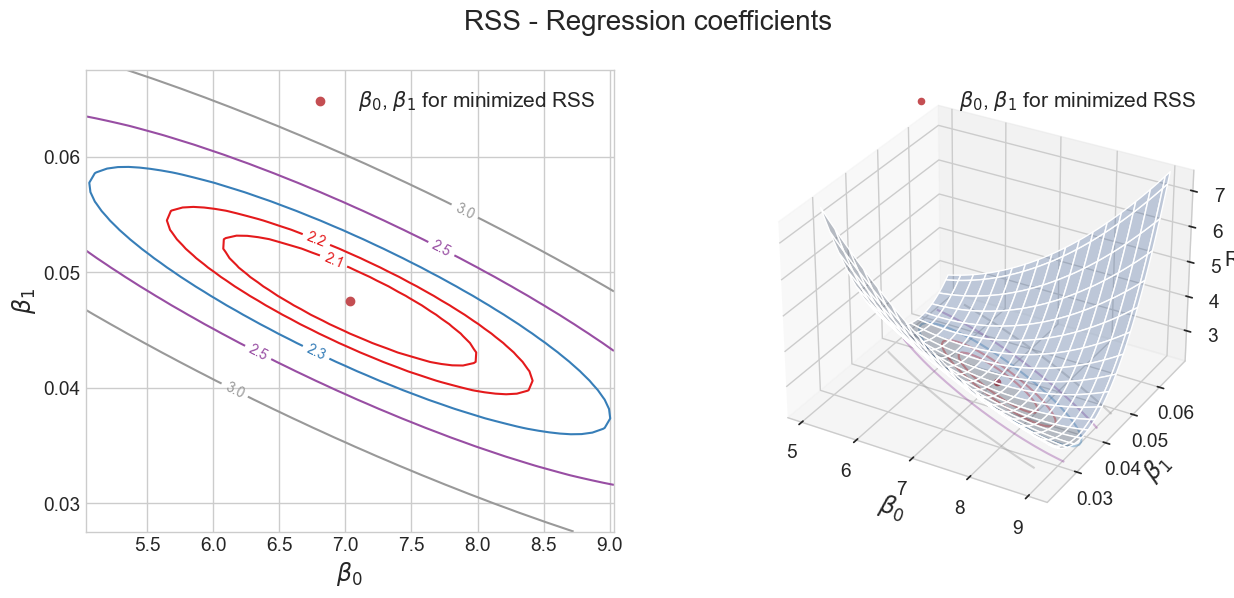

In [9]:
fig = plt.figure(figsize=(15,6))
fig.suptitle('RSS - Regression coefficients', fontsize=20)

ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122, projection='3d')

# Left plot
CS = ax1.contour(xx, yy, Z, cmap=plt.cm.Set1, levels=[2.15, 2.2, 2.3, 2.5, 3])
ax1.scatter(regr.intercept_, regr.coef_[0], c='r', label=min_RSS)
ax1.clabel(CS, inline=True, fontsize=10, fmt='%1.1f')

# Right plot
ax2.plot_surface(xx, yy, Z, rstride=3, cstride=3, alpha=0.3)
ax2.contour(xx, yy, Z, zdir='z', offset=Z.min(), cmap=plt.cm.Set1,
            alpha=0.4, levels=[2.15, 2.2, 2.3, 2.5, 3])
ax2.scatter3D(regr.intercept_, regr.coef_[0], min_rss, c='r', label=min_RSS)
ax2.set_zlabel('RSS')
ax2.set_zlim(Z.min(),Z.max())
ax2.set_ylim(0.02,0.07)

# settings common to both plots
for ax in fig.axes:
    ax.set_xlabel(r'$\beta_0$', fontsize=17)
    ax.set_ylabel(r'$\beta_1$', fontsize=17)
    ax.set_yticks([0.03,0.04,0.05,0.06])
    ax.legend(fontsize=15)

These level curves don't look quite right, and it's because in the book they scale the data before fitting it, so it has mean 0. We'll do that next and see that our level curves look "better". We'll get into what "better" means later in this notebook.

In [10]:
X = scale(advertising.TV, with_mean=True, with_std=False).reshape(-1,1)
y = advertising.sales
regr.fit(X,y)
print('\n')
print(regr.intercept_)
print(regr.coef_)

LinearRegression()



14.0225
[0.04753664]


Note that we get the same slope but a different intercept. Subtracting the mean from the x-values simply shifts the data (and the best fit line) to the left.

<Axes: ylabel='sales'>

(-160.0, 160.0)

(-5.0, 28.27)

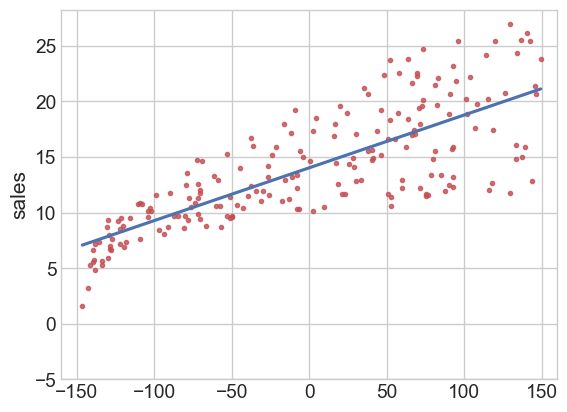

In [11]:
sns.regplot(x = scale(advertising.TV, with_mean=True, with_std=False), y = advertising.sales, order=1, ci=None, scatter_kws={'color':'r', 's':9})
plt.xlim(-160,160)
plt.ylim(ymin=-5)

Let's see if the RSS curves are more useful.

In [12]:
# Create grid coordinates for plotting
B0 = np.linspace(regr.intercept_-2, regr.intercept_+2, 50)
B1 = np.linspace(regr.coef_-0.02, regr.coef_+0.02, 50)
xx, yy = np.meshgrid(B0, B1, indexing='xy')
Z = np.zeros((B0.size,B1.size))

# Calculate Z-values (RSS) based on grid of coefficients
for (i,j),v in np.ndenumerate(Z):
    Z[i,j] =((y - (xx[i,j]+X.ravel()*yy[i,j]))**2).sum()/1000

# Minimized RSS
min_RSS = r'$\beta_0$, $\beta_1$ for minimized RSS'
min_rss = np.sum((regr.intercept_+regr.coef_*X - y.values.reshape(-1,1))**2)/1000
min_rss

2.1025305831313514

Note that we get the same minimum RSS

Text(0.5, 0.98, 'RSS - Regression coefficients')

<a list of 8 text.Text objects>

Text(0.5, 0, 'RSS')

(2.1031081456517593, 3.4892581946313563)

(0.02, 0.07)

Text(0.5, 0, '$\\beta_0$')

Text(0, 0.5, '$\\beta_1$')

Text(0.5, 0, '$\\beta_0$')

Text(0.5, 0.5, '$\\beta_1$')

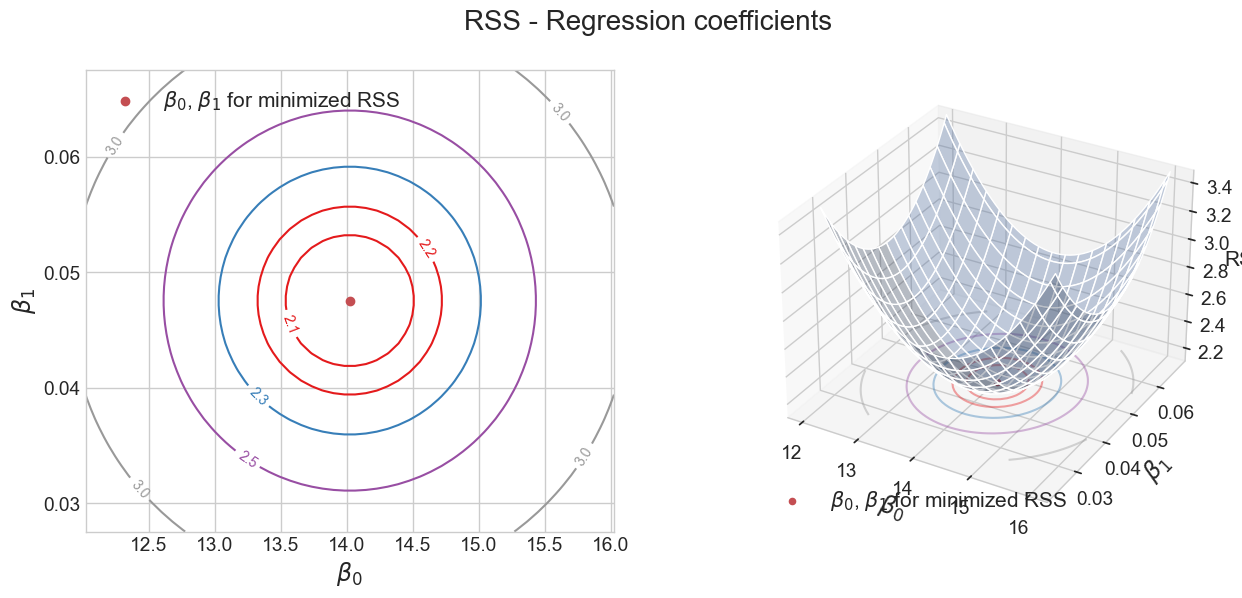

In [13]:
fig = plt.figure(figsize=(15,6))
fig.suptitle('RSS - Regression coefficients', fontsize=20)

ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122, projection='3d')

# Left plot
CS = ax1.contour(xx, yy, Z, cmap=plt.cm.Set1, levels=[2.15, 2.2, 2.3, 2.5, 3])
ax1.scatter(regr.intercept_, regr.coef_[0], c='r', label=min_RSS)
ax1.clabel(CS, inline=True, fontsize=10, fmt='%1.1f')

# Right plot
ax2.plot_surface(xx, yy, Z, rstride=3, cstride=3, alpha=0.3)
ax2.contour(xx, yy, Z, zdir='z', offset=Z.min(), cmap=plt.cm.Set1,
            alpha=0.4, levels=[2.15, 2.2, 2.3, 2.5, 3])
ax2.scatter3D(regr.intercept_, regr.coef_[0], min_rss, c='r', label=min_RSS)
ax2.set_zlabel('RSS')
ax2.set_zlim(Z.min(),Z.max())
ax2.set_ylim(0.02,0.07)

# settings common to both plots
for ax in fig.axes:
    ax.set_xlabel(r'$\beta_0$', fontsize=17)
    ax.set_ylabel(r'$\beta_1$', fontsize=17)
    ax.set_yticks([0.03,0.04,0.05,0.06])
    ax.legend(fontsize=15)

Now we can clearly see that the RSS is mimized at the coefficients our model identified ($\beta_0$ = 14.0225, $\beta_1$ = 0.0475), and even if the data shifted slightly, we'd likely get to the same value (or close).

Now that we have coefficient estimates, we need to evaluate how accurate they are. First, as in Table 3.1, we identify standard error, t-values, and p-values for our coefficients, along with a confidence interval. In both cases, the t values are high, the p values are low, and the confidence interval does not contain 0, so we can be confident that both the "true" slope and intercept are different from 0. In fact, a TV coefficient of 0.475 indicates an increase of about 50 units for an increase of $1,000 in the TV advertising budget.

In [14]:
est = smf.ols('sales ~ TV', advertising).fit()
est.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,7.0326,0.458,15.360,0.000,6.130,7.935
TV,0.0475,0.003,17.668,0.000,0.042,0.053


The full summary gives us the $R^2$ and F-statistic, as in Table 3.2.


In [15]:
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           1.47e-42
Time:                        13:56:21   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.0326      0.458     15.360      0.000       6.130       7.935
TV             0.0475      0.003     17.668      0.000       0.042       0.053
==============================================================================
Omnibus:                        0.531   Durbin-Watson:                   1.935
Prob(Omnibus):                  0.767   Jarque-Bera (JB):                0.669
Skew:                          -0.089   Prob(JB):                        0.716
Kurtosis:                       2.779   Cond. No.                         338.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

We can also get the residual standard error as below.

In [16]:
est.scale ** 0.5

3.258656368650462

### Multiple Linear Regression

When you have more than one predictor, running separate simple regressions for each one is tempting but misleading. The problem is that predictors often correlate with each other. If TV and radio spending tend to increase together, then a simple regression of sales on TV spending will absorb some of the radio effect too — inflating the TV coefficient. You can't tell what's really driving sales.

Multiple linear regression solves this by fitting all predictors simultaneously. The coefficient for each predictor now represents its effect on the outcome *while holding all other predictors constant*. This is a much more honest accounting of each variable's contribution.

### How to interpret multiple regression output

Each coefficient still has the same interpretation: "for a one-unit increase in this predictor, how much does the outcome change, assuming all other predictors stay the same?"

The p-value next to each coefficient tells you whether that predictor's relationship with the outcome is statistically distinguishable from zero — i.e., whether it's likely to be a real effect or could just be noise.

A predictor might be significant in a simple regression but not in a multiple regression (or vice versa). This often happens because of **confounding**: one variable appears important only because it's correlated with another variable that's the true driver.

In our advertising example, we also have data for advertising on radio and newspapers, not just TV data. We'll include those by using multiple linear regression.

First, as shown in Table 3.3, both radio and newspaper advertising have a statistically significant impact on sales.

In [17]:
est = smf.ols('sales ~ radio', advertising).fit()
est.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,9.3116,0.563,16.542,0.000,8.202,10.422
radio,0.2025,0.020,9.921,0.000,0.162,0.243


In [18]:
est = smf.ols('sales ~ newspaper', advertising).fit()
est.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,12.3514,0.621,19.876,0.000,11.126,13.577
newspaper,0.0547,0.017,3.300,0.001,0.022,0.087


Next, we'll consider a regression with all three predictors.

In [19]:
est = smf.ols('sales ~ TV + radio + newspaper', advertising).fit()
est.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,2.9389,0.312,9.422,0.000,2.324,3.554
TV,0.0458,0.001,32.809,0.000,0.043,0.049
radio,0.1885,0.009,21.893,0.000,0.172,0.206
newspaper,-0.0010,0.006,-0.177,0.860,-0.013,0.011


Based on the p-values, it looks like the TV and Radio spending are statistically significant, while newspaper spending is not. This may be counter-intuitive since in the simple regression case, newspaper spending was statistically significant. Let's look at the correlaton matrix here.

In [20]:
advertising.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


Because newspaper and radio spending have correlation of 0.35, it's likely that sales are higher in markets with a lot of radio advertising; because of the correlation, those markets have higher newspaper advertising too, which shows up in the simple regression on newspaper advertising.

The absurd example is a regression of shark attacks against ice cream sales. A simple linear regression would show a strong relationship between ice cream sales and shark attacks, similar to the one shown between newspaper advertisements and sales. In reality, a third (latent) variable, temperature, drives both ice cream sales and shark attacks by driving people to the beach. A multiple regression would show that ice cream sales is not a significant driver of shark attacks if temperature is also included as a predictor. In our example, newspaper advertising is not a driver of sales, but we can only see that by looking at the multiple linear regression.

We can also look at additional statistics like $R^2$, F-statistic, and RSE.

In [21]:
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           1.58e-96
Time:                        13:56:21   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9389      0.312      9.422      0.000       2.324       3.554
TV             0.0458      0.001     32.809      0.000       0.043       0.049
radio          0.1885      0.009     21.893      0.000       0.172       0.206
newspaper     -0.0010      0.006     -0.177      0.860      -0.013       0.011
==============================================================================
Omnibus:                       60.414   Durbin-Watson:                   2.084
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              151.241
Skew:                          -1.327   Prob(JB):                     1.44e-33
Kurtosis:                       6.332   Cond. No.                         454.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [22]:
est.scale ** 0.5

1.685510373414744

Finally, let's take a look at the "least squares plane" (analagous to the least squares line) for our example, based on the statistically significant variables, radio advertising and TV advertising.

In [23]:
regr = skl_lm.LinearRegression()

X = advertising[['radio', 'TV']]
y = advertising.sales

regr.fit(X,y)
print('\n')
print(regr.coef_)
print(regr.intercept_)

LinearRegression()



[0.18799423 0.04575482]
2.9210999124051433


In [24]:
# Create a coordinate grid
Radio = np.arange(0,50)
TV = np.arange(0,300)

B1, B2 = np.meshgrid(Radio, TV, indexing='xy')
Z = np.zeros((TV.size, Radio.size))

for (i,j),v in np.ndenumerate(Z):
        Z[i,j] =(regr.intercept_ + B1[i,j]*regr.coef_[0] + B2[i,j]*regr.coef_[1])

# We'll also add a column to color points above the plane green and below the plane red
advertising['color'] = np.where(advertising.sales > regr.intercept_ + advertising.radio * regr.coef_[0] + advertising.TV * regr.coef_[1], 'g', 'r')

Text(0.5, 0.98, 'Regression: Sales ~ Radio + TV Advertising')

<Axes3D: >

Text(0.5, 0, 'Radio')

(0.0, 50.0)

Text(0.5, 0.5, 'TV')

(0.0, 320.8020833333333)

Text(0.5, 0, 'Sales')

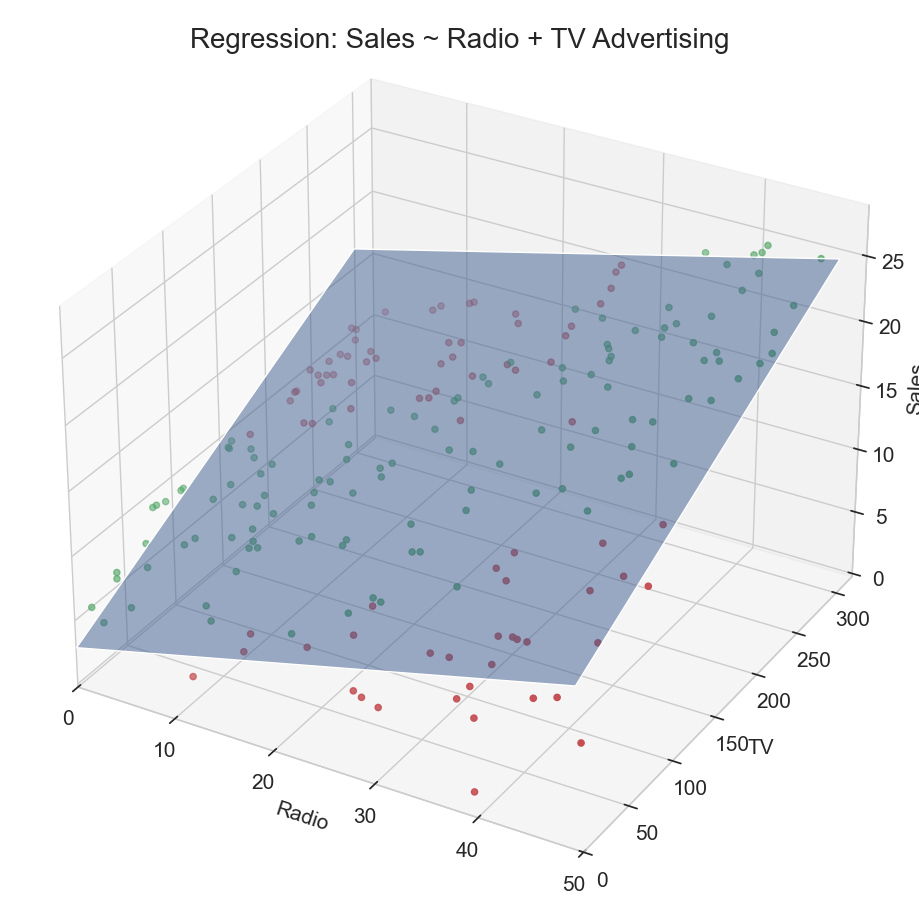

In [25]:
# Create plot
fig = plt.figure(figsize=(15,9))
fig.suptitle('Regression: Sales ~ Radio + TV Advertising', fontsize=20)

ax = axes3d.Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)

ax.plot_surface(B1, B2, Z, rstride=500, cstride=500, alpha=0.5)
ax.scatter3D(advertising.radio, advertising.TV, advertising.sales, c=advertising.color)

ax.set_xlabel('Radio', size = 15)
ax.set_xlim(0,50)
ax.set_ylabel('TV', size = 15)
ax.set_ylim(bottom=0)
ax.set_zlabel('Sales', size = 15)
ax.tick_params(axis='both', which='major', labelsize=15)

Looking at the residuals, it looks pretty clear that there is a non-linear relationship in the data. The positive residuals are along the 45-degree line, where TV and radio budgets are split evenly. The negative resituals are mostly away from this line, where budgets are lopsided. This suggests some interaction effect, where combining the media (radio and TV) results in a bigger boost to sales than using only one.

### Interaction Terms

Standard multiple linear regression assumes that the effect of each predictor is the same regardless of the values of the other predictors. But this isn't always true.

Consider TV and radio advertising. Maybe TV ads are more effective in markets where radio advertising is also heavy — people see the TV ad and hear the radio ad and the combined effect is greater than the sum of the parts. This is an **interaction effect**.

To capture this, we create a new variable that is the product of TV and radio spending, and include it as a predictor. The coefficient on this product term tells us how much the effect of TV advertising changes for each unit increase in radio advertising (and vice versa — the relationship is symmetric).

When an interaction term is statistically significant, it means the two predictors don't just add up independently — they amplify or dampen each other's effect.

To handle the pattern in the residuals above, we can use TV advertising multiplied by radio advertising, to capture the interaction effect.



In [26]:
est = smf.ols('sales ~ TV + radio + TV*radio', advertising).fit()
est.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,6.7502,0.248,27.233,0.000,6.261,7.239
TV,0.0191,0.002,12.699,0.000,0.016,0.022
radio,0.0289,0.009,3.241,0.001,0.011,0.046
TV:radio,0.0011,5.24e-05,20.727,0.000,0.001,0.001


As expected, our TV * radio interaction term is statiscially significant.

In [27]:
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     1963.
Date:                Fri, 10 Apr 2026   Prob (F-statistic):          6.68e-146
Time:                        13:56:21   Log-Likelihood:                -270.14
No. Observations:                 200   AIC:                             548.3
Df Residuals:                     196   BIC:                             561.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.7502      0.248     27.233      0.000       6.261       7.239
TV             0.0191      0.002     12.699      0.000       0.016       0.022
radio          0.0289      0.009      3.241      0.001       0.011       0.046
TV:radio       0.0011   5.24e-05     20.727      0.000       0.001       0.001
==============================================================================
Omnibus:                      128.132   Durbin-Watson:                   2.224
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1183.719
Skew:                          -2.323   Prob(JB):                    9.09e-258
Kurtosis:                      13.975   Cond. No.                     1.80e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.8e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The $R^2$ value and F-statistic indicate a strong relationship here.

In [28]:
est.scale ** 0.5

0.9435154158451168

We've also reduced the residual standard error quite a bit.

## Credit Data

Our next example looks at credit data including balance, as well as quantitative predictors like age, number of cards, education (in years), income (in thousands), credit limit, and credit rating, along with categorical variables, like gender, student status, marital status, and ethnicity.


In [29]:
url2 = 'https://raw.githubusercontent.com/dsahota-applied-data-analysis/data/main/Credit.csv'
credit = pd.read_csv(url2, usecols=list(range(1,12)))
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Income     400 non-null    float64
 1   Limit      400 non-null    int64  
 2   Rating     400 non-null    int64  
 3   Cards      400 non-null    int64  
 4   Age        400 non-null    int64  
 5   Education  400 non-null    int64  
 6   Gender     400 non-null    object 
 7   Student    400 non-null    object 
 8   Married    400 non-null    object 
 9   Ethnicity  400 non-null    object 
 10  Balance    400 non-null    int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 34.5+ KB


In [30]:
credit.head()

,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


We can use pairplot to get a look at the variables. The diagonal is a histogram while the non-diagonals are scatterplots.

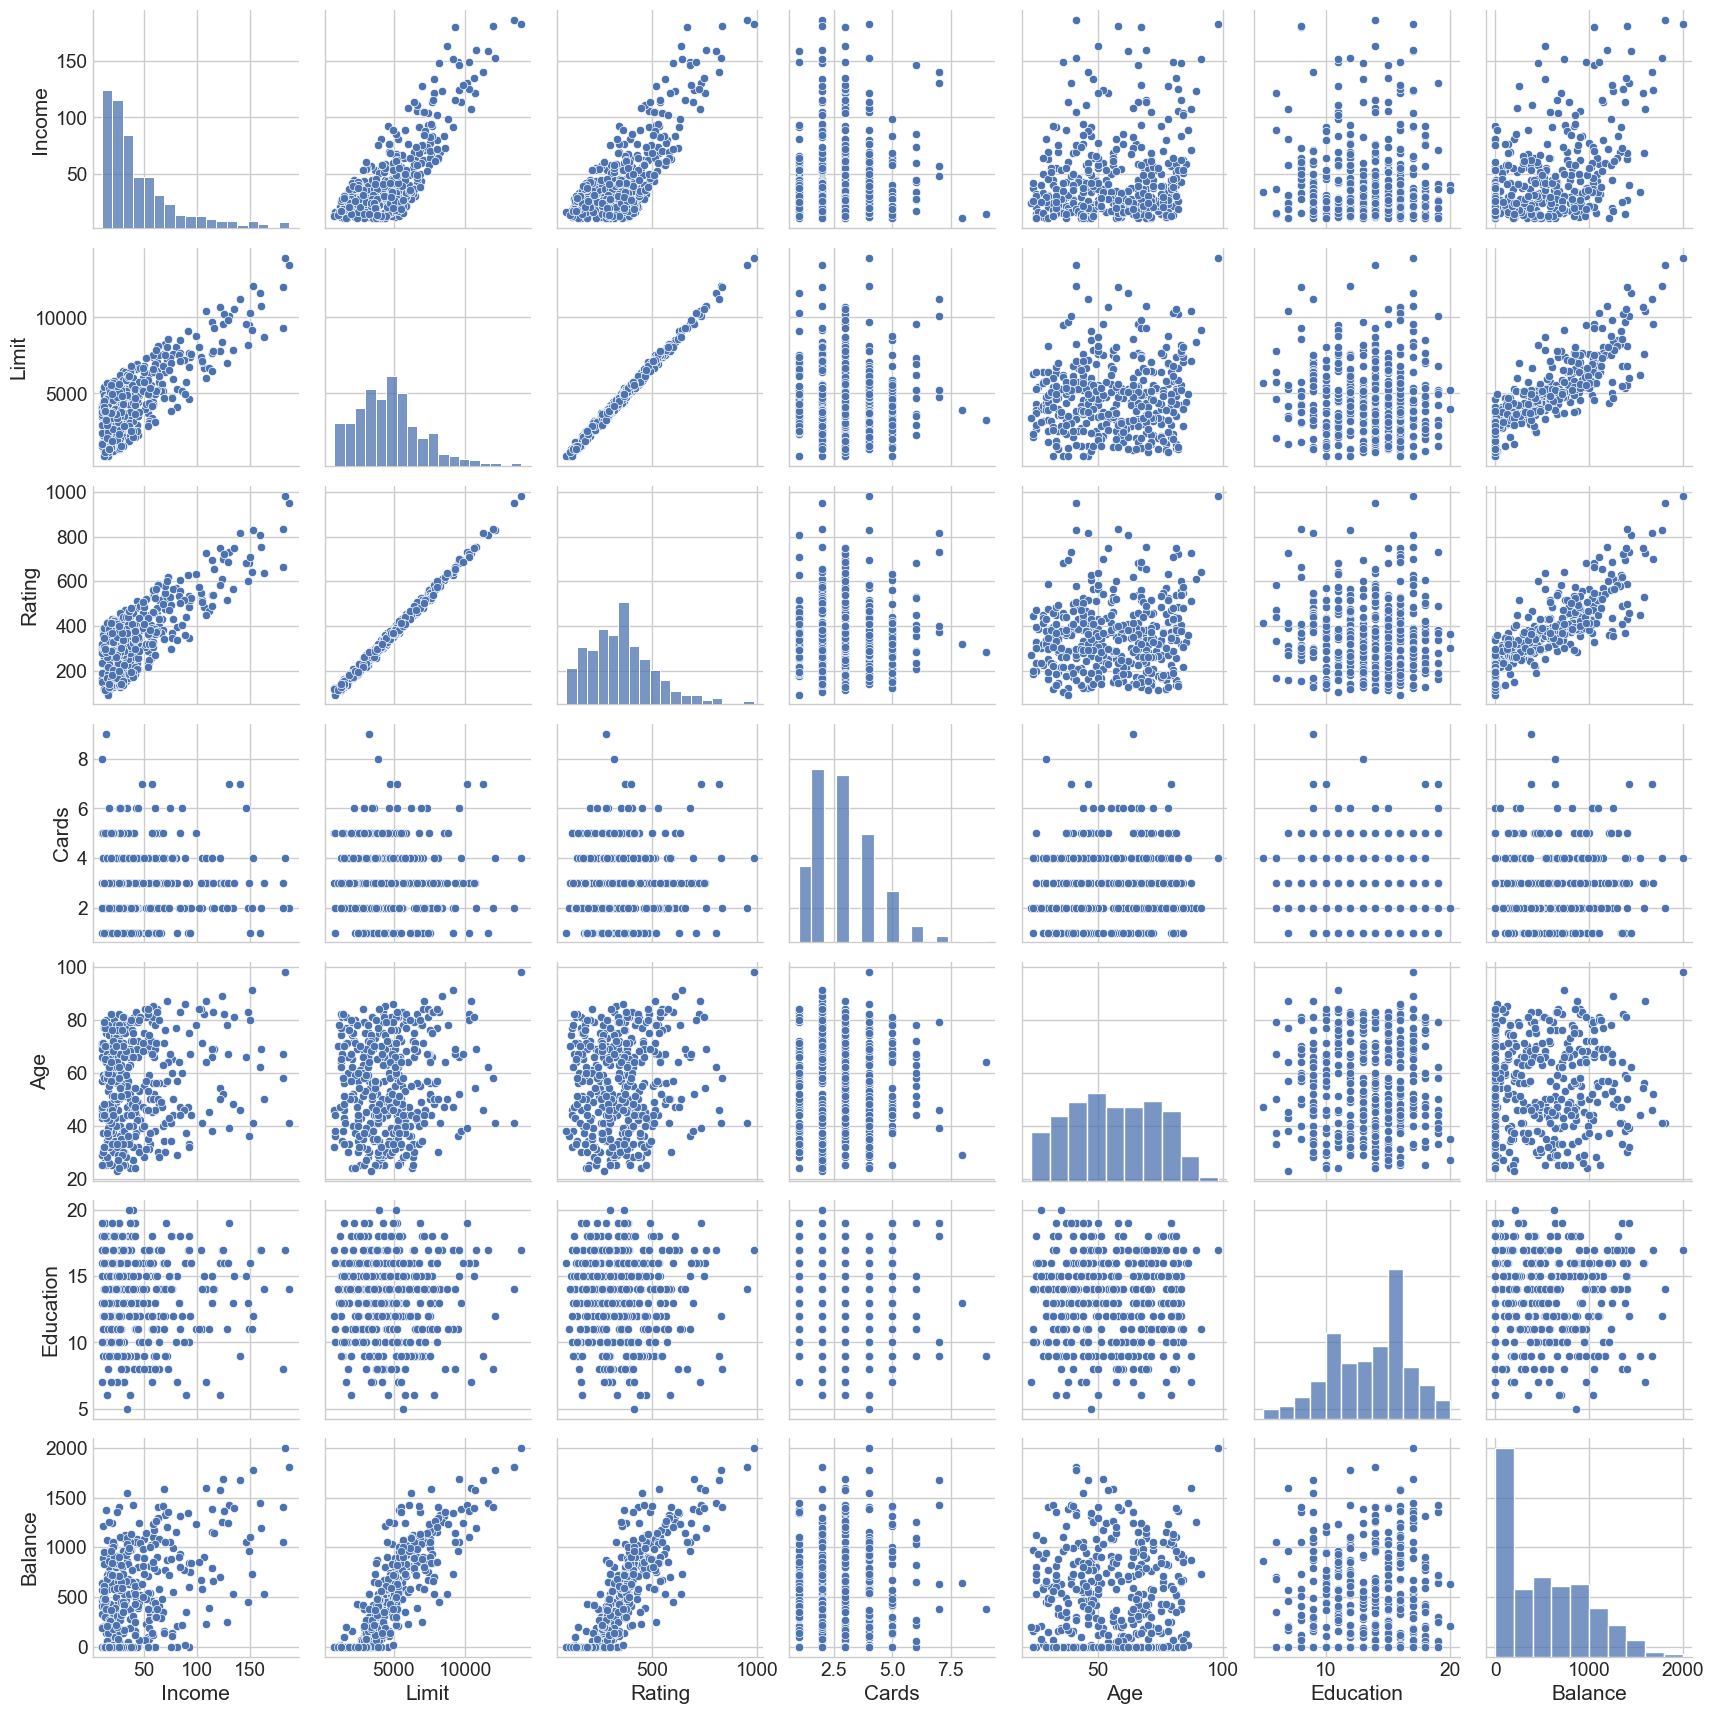

In [31]:
# Pairplot ignores categorical variables
sns.pairplot(credit)

### Encoding Categorical Variables

When we have a categorical variable that has two values (gender), we introduce a single dummy variable which is 1 for one value (Male) and 0 for the other (Female), and complete our linear regression. Using statsmodels, this is done for us automatically.

In [32]:
est = smf.ols('Balance ~ Gender', credit).fit()
est.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,529.5362,31.988,16.554,0.000,466.649,592.423
Gender[T.Male],-19.7331,46.051,-0.429,0.669,-110.267,70.801


In this example, based on the low t-value and high p-value, and that the confidence interval contains 0, gender is not statistically significant as a predictor, so there is no statististical evidence of a difference in average credit card balances between the genders.

When we have a categorical variable with multiple values, we have to do something different. In our example, ethnicity takes on three possible values; Asian, Caucasian, or African American. With three possible values, we use two dummy variables (one for Asian, one for Caucasian), and if both are zero, value is African American. In this case, even though we only have one predictor, encoding with dummy variables causes us to use a multiple linear regression.

In [33]:
est = smf.ols('Balance ~ Ethnicity', credit).fit()
est.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,531.0000,46.319,11.464,0.000,439.939,622.061
Ethnicity[T.Asian],-18.6863,65.021,-0.287,0.774,-146.515,109.142
Ethnicity[T.Caucasian],-12.5025,56.681,-0.221,0.826,-123.935,98.930


Based on the low t-values and high p-values, and that the confidence intervals contain 0, neither ethnicity value is statistically significant as a predictor, so there is no statistical evidence of a difference in average credit card balances between the ethnicities.

### Interaction Terms Between Quantitative and Qualitative Predictors

In this example, we'll fit two regressions for predicting credit balance based on income and whether or not someone is a student. The model on the left uses no interaction terms, and we end up with two parallel lines (the vertical shift between the lines is the coefficient of the student dummy variable). For the model on the right, we use an interaction term, which allows for the lines to have different slopes.

In [34]:
est1 = smf.ols('Balance ~ Income + Student', credit).fit()
regr1 = est1.params
est2 = smf.ols('Balance ~ Income + Income*Student', credit).fit()
regr2 = est2.params

print('Regression 1 - without interaction term')
print(regr1)
print('\nRegression 2 - with interaction term')
print(regr2)

Regression 1 - without interaction term
Intercept         211.142964
Student[T.Yes]    382.670539
Income              5.984336
dtype: float64

Regression 2 - with interaction term
Intercept                200.623153
Student[T.Yes]           476.675843
Income                     6.218169
Income:Student[T.Yes]     -1.999151
dtype: float64


Text(0.5, 0, 'Income')

Text(0, 0.5, 'Balance')

(147.12692071801297, 1550.0)

Text(0.5, 0, 'Income')

Text(0, 0.5, 'Balance')

(145.1467267986485, 1550.0)

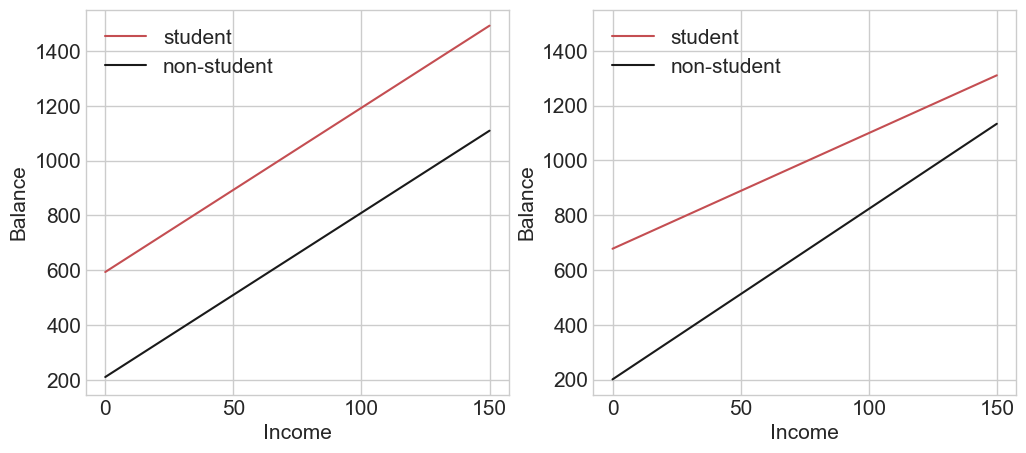

In [35]:
# Income (x-axis)
income = np.linspace(0,150)

# Balance without interaction term (y-axis)
student1 = np.linspace(regr1['Intercept']+regr1['Student[T.Yes]'],
                       regr1['Intercept']+regr1['Student[T.Yes]']+150*regr1['Income'])
non_student1 =  np.linspace(regr1['Intercept'], regr1['Intercept']+150*regr1['Income'])

# Balance with iteraction term (y-axis)
student2 = np.linspace(regr2['Intercept']+regr2['Student[T.Yes]'],
                       regr2['Intercept']+regr2['Student[T.Yes]']+
                       150*(regr2['Income']+regr2['Income:Student[T.Yes]']))
non_student2 =  np.linspace(regr2['Intercept'], regr2['Intercept']+150*regr2['Income'])

# Create plot
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,5))
ax1.plot(income, student1, 'r', income, non_student1, 'k')
ax2.plot(income, student2, 'r', income, non_student2, 'k')

for ax in fig.axes:
    ax.legend(['student', 'non-student'], loc=2, fontsize=15)
    ax.set_xlabel('Income', size=15)
    ax.set_ylabel('Balance', size=15)
    ax.set_ylim(ymax=1550)
    ax.tick_params(axis='both', which='major', labelsize=15)

### Non-linear Relationships and Polynomial Features

Linear regression assumes a straight-line relationship between each predictor and the outcome. But what if the true relationship is curved — for example, fuel efficiency might drop quickly at first as horsepower increases, then level off?

One way to handle this while still using linear regression is to add **polynomial terms** — squared, cubed, or higher powers of the predictor. We create a new column that is the square of horsepower and include it as an additional predictor. The model is still "linear" in the sense that we're fitting a linear combination of these features, but the resulting curve is now quadratic (or higher degree) in the original predictor.

The key question is how high to go. A degree-2 polynomial fits a parabola, which might be enough. A degree-5 polynomial can take on wild, wiggly shapes and may overfit the data. Residual plots help judge: if there's still a visible pattern in the residuals after fitting a degree-2 model, higher-order terms might help.

### What residual plots tell us

After fitting a model, we plot the residuals (prediction errors) on the y-axis against the fitted values (or one of the predictors) on the x-axis. If the model is a good fit, the residuals should look like random noise — no pattern, no trend, no funnel shape.

Common patterns and what they mean:
- **A curved pattern**: the relationship is non-linear and the model is missing it. Try polynomial features or a different model.
- **A funnel shape** (errors get larger as fitted values increase): the variance of the errors is not constant — called heteroscedasticity. May need to transform the outcome variable.
- **Points far from zero**: possible outliers that deserve a closer look.

In this example, we'll consider the Auto data set.

In [36]:
url3 = 'https://raw.githubusercontent.com/dsahota-applied-data-analysis/data/main/Auto.csv'
auto = pd.read_csv(url3, na_values='?').dropna()
auto.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   name          392 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 30.6+ KB


In [37]:
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


It's possible that mpg is dependent on horsepower. We can try linear regression to examine the fit.

<Axes: xlabel='horsepower', ylabel='mpg'>

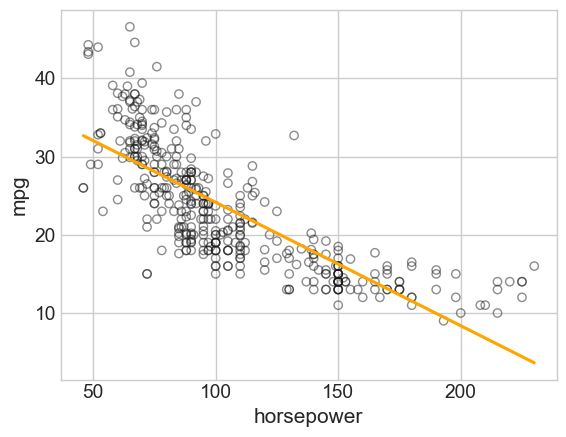

In [38]:
plt.scatter(x=auto.horsepower, y=auto.mpg, facecolors='None', edgecolors='k', alpha=.5)
sns.regplot(x=auto.horsepower, y=auto.mpg, ci=None, label='Linear', scatter=False, color='orange')

In [39]:
est = smf.ols('mpg ~ horsepower', auto).fit()
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           7.03e-81
Time:                        13:56:24   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     39.9359      0.717     55.660      0.000      38.525      41.347
horsepower    -0.1578      0.006    -24.489      0.000      -0.171      -0.145
==============================================================================
Omnibus:                       16.432   Durbin-Watson:                   0.920
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               17.305
Skew:                           0.492   Prob(JB):                     0.000175
Kurtosis:                       3.299   Cond. No.                         322.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [40]:
est.ssr

9385.915871932419

In fact, the coefficient of horsepower is significant, but the overall performance of this model seems poor, based on the high RSS.

To examine this further, we'll look at a plot of the residuals.

<Axes: >

(0.0, 40.0)

Text(0.5, 0, 'Fitted Values')

(array([ 0.,  5., 10., 15., 20., 25., 30., 35., 40.]),
 [Text(0.0, 0, '0'),
  Text(5.0, 0, '5'),
  Text(10.0, 0, '10'),
  Text(15.0, 0, '15'),
  Text(20.0, 0, '20'),
  Text(25.0, 0, '25'),
  Text(30.0, 0, '30'),
  Text(35.0, 0, '35'),
  Text(40.0, 0, '40')])

(array([-20., -15., -10.,  -5.,   0.,   5.,  10.,  15.,  20.]),
 [Text(0, -20.0, '−20'),
  Text(0, -15.0, '−15'),
  Text(0, -10.0, '−10'),
  Text(0, -5.0, '−5'),
  Text(0, 0.0, '0'),
  Text(0, 5.0, '5'),
  Text(0, 10.0, '10'),
  Text(0, 15.0, '15'),
  Text(0, 20.0, '20')])

Text(0, 0.5, 'Residuals')

Text(0.5, 1.0, 'Residual Plot for Linear Fit')

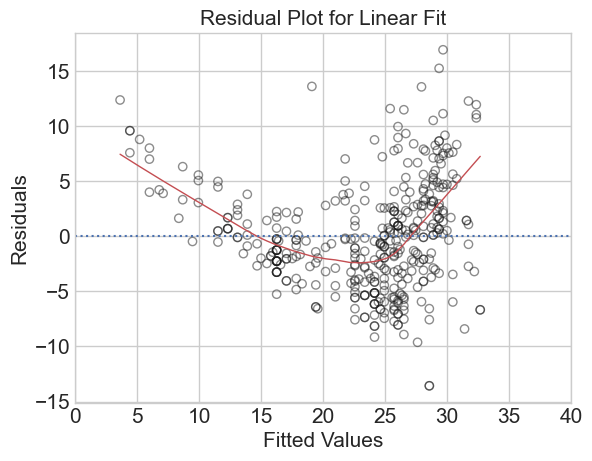

In [41]:
sns.regplot(x = est.fittedvalues, y = est.resid, lowess=True,
            line_kws={'color':'r', 'lw':1},
            scatter_kws={'facecolors':'None', 'edgecolors':'k', 'alpha':0.5})
plt.hlines(0, xmin=0, xmax=40, linestyles='dotted')
plt.xlim(0,40)
plt.xlabel('Fitted Values', size=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel('Residuals', size=15)
plt.title('Residual Plot for Linear Fit', size=15)
plt.show()

The red line is a smooth fit for the residuals, intended to make a trend more visible. In this case, it looks like there's a strong pattern, indicating non-linearity, and we might guess that this looks quadratic, or degree 2. Let's see how a few higher degree polynomials look.

<Axes: xlabel='horsepower', ylabel='mpg'>

<Axes: xlabel='horsepower', ylabel='mpg'>

<Axes: xlabel='horsepower', ylabel='mpg'>

Text(0.5, 1.0, 'Polynomial Regression of Miles Per Gallon against Horsepower')

Text(0.5, 0, 'Horsepower')

Text(0, 0.5, 'Miles Per Gallon')

(array([  0.,  50., 100., 150., 200., 250.]),
 [Text(0.0, 0, '0'),
  Text(50.0, 0, '50'),
  Text(100.0, 0, '100'),
  Text(150.0, 0, '150'),
  Text(200.0, 0, '200'),
  Text(250.0, 0, '250')])

(array([ 0., 10., 20., 30., 40., 50.]),
 [Text(0, 0.0, '0'),
  Text(0, 10.0, '10'),
  Text(0, 20.0, '20'),
  Text(0, 30.0, '30'),
  Text(0, 40.0, '40'),
  Text(0, 50.0, '50')])

(5.0, 55.0)

(40.0, 240.0)

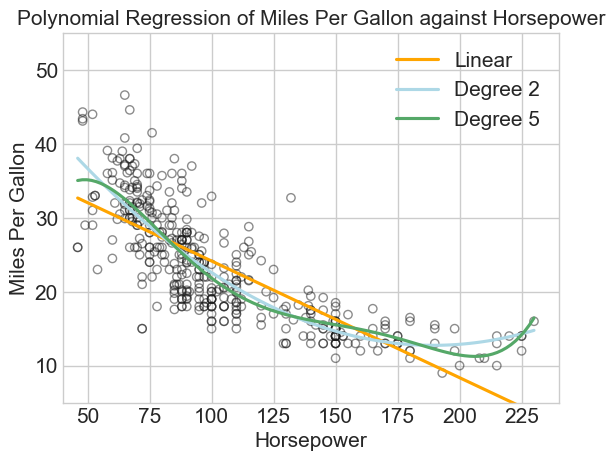

In [42]:
plt.scatter(auto.horsepower, auto.mpg, facecolors='None', edgecolors='k', alpha=.5)
sns.regplot(x=auto.horsepower, y=auto.mpg, ci=None, label='Linear', scatter=False, color='orange')
sns.regplot(x=auto.horsepower, y=auto.mpg, ci=None, label='Degree 2', order=2, scatter=False, color='lightblue')
sns.regplot(x=auto.horsepower, y=auto.mpg, ci=None, label='Degree 5', order=5, scatter=False, color='g')
plt.legend(fontsize=15)
plt.title('Polynomial Regression of Miles Per Gallon against Horsepower', size=15)
plt.xlabel('Horsepower', size=15)
plt.ylabel('Miles Per Gallon', size=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylim(5,55)
plt.xlim(40,240)

Here it looks like degree 2 could be a good fit for the data, while degree 5 seems unnecessarily wiggly.

In [43]:
auto['horsepower2'] = auto.horsepower**2
est = smf.ols('mpg ~ horsepower + horsepower2', auto).fit()
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     428.0
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           5.40e-99
Time:                        13:56:25   Log-Likelihood:                -1133.2
No. Observations:                 392   AIC:                             2272.
Df Residuals:                     389   BIC:                             2284.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      56.9001      1.800     31.604      0.000      53.360      60.440
horsepower     -0.4662      0.031    -14.978      0.000      -0.527      -0.405
horsepower2     0.0012      0.000     10.080      0.000       0.001       0.001
==============================================================================
Omnibus:                       16.158   Durbin-Watson:                   1.078
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               30.662
Skew:                           0.218   Prob(JB):                     2.20e-07
Kurtosis:                       4.299   Cond. No.                     1.29e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.29e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

By adding the horsepower$^2$ term, our R-squared improved quite a bit and the coefficient of horsepower$^2$ is statistically significant. Why not try a much higher order polynomial then?

In [44]:
auto['horsepower3'] = auto.horsepower**3
auto['horsepower4'] = auto.horsepower**4
auto['horsepower5'] = auto.horsepower**5
est = smf.ols('mpg ~ horsepower + horsepower2 + horsepower3 + horsepower4 + horsepower5', auto).fit()
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.693
Method:                 Least Squares   F-statistic:                     177.4
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           1.16e-97
Time:                        13:56:25   Log-Likelihood:                -1127.3
No. Observations:                 392   AIC:                             2267.
Df Residuals:                     386   BIC:                             2290.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     -32.2306     28.574     -1.128      0.260     -88.411      23.950
horsepower      3.7001      1.303      2.840      0.005       1.139       6.262
horsepower2    -0.0714      0.023     -3.170      0.002      -0.116      -0.027
horsepower3     0.0006      0.000      3.206      0.001       0.000       0.001
horsepower4 -2.281e-06   7.24e-07     -3.150      0.002   -3.71e-06   -8.57e-07
horsepower5   3.33e-09   1.09e-09      3.068      0.002     1.2e-09    5.46e-09
==============================================================================
Omnibus:                       20.902   Durbin-Watson:                   1.113
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               40.260
Skew:                           0.305   Prob(JB):                     1.81e-09
Kurtosis:                       4.447   Cond. No.                     1.32e+13
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.32e+13. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Here we see that although the degree 3, 4, and 5 coefficients are statistically significant, they are all very close to zero, and could indicate we are following the weeds of the data too closely. This is an example where a model that is too complex or flexibile is prone to overfitting.

Finally, we can compare the residuals of our quadratic (degree 2) model to the linear model, as shown in Figure 3.9.

In [45]:
est1 = smf.ols('mpg ~ horsepower', auto).fit()
est2 = smf.ols('mpg ~ horsepower + horsepower2', auto).fit()

<Axes: >

Text(0.5, 1.0, 'Residual Plot for Linear Fit')

<Axes: >

Text(0.5, 1.0, 'Residual Plot for Quadratic Fit')

Text(0.5, 0, 'Fitted values')

Text(0, 0.5, 'Residuals')

Text(0.5, 0, 'Fitted values')

Text(0, 0.5, 'Residuals')

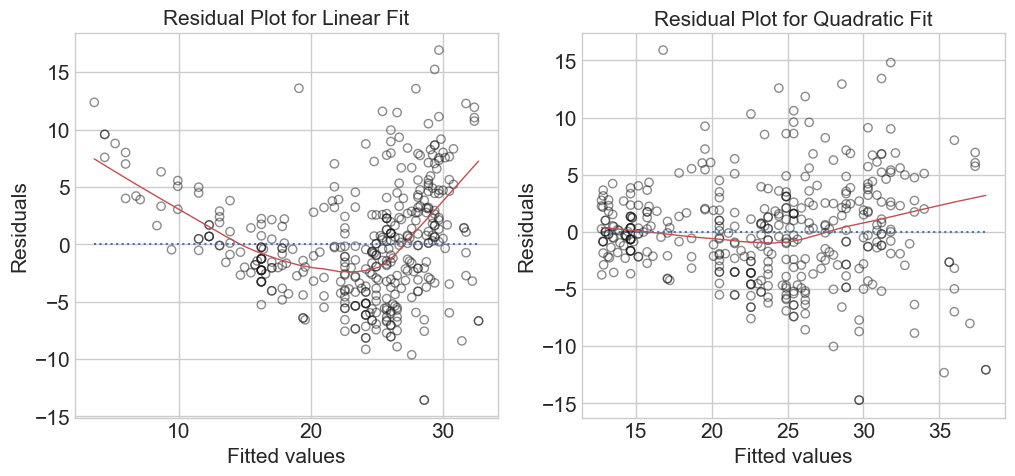

In [46]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,5))

# Left plot
sns.regplot(x=est1.fittedvalues, y=est1.resid, lowess=True,
            ax=ax1, line_kws={'color':'r', 'lw':1},
            scatter_kws={'facecolors':'None', 'edgecolors':'k', 'alpha':0.5})
ax1.hlines(0,xmin=ax1.xaxis.get_data_interval()[0],
            xmax=ax1.xaxis.get_data_interval()[1], linestyles='dotted')
ax1.set_title('Residual Plot for Linear Fit', size = 15)

# Right plot
sns.regplot(x=est2.fittedvalues, y=est2.resid, lowess=True,
            line_kws={'color':'r', 'lw':1}, ax=ax2,
            scatter_kws={'facecolors':'None', 'edgecolors':'k', 'alpha':0.5})
ax2.hlines(0,xmin=ax2.xaxis.get_data_interval()[0],
            xmax=ax2.xaxis.get_data_interval()[1], linestyles='dotted')
ax2.set_title('Residual Plot for Quadratic Fit', size = 15)

for ax in fig.axes:
    ax.set_xlabel('Fitted values', size=15)
    ax.set_ylabel('Residuals', size=15)
    ax.tick_params(axis='x', labelsize=15)
    ax.tick_params(axis='y', labelsize=15)

For the quadratic fit, there is little pattern in the residuals, indicating the quadratic term improves the fit to the data.

### Collinearity

**Collinearity** (or multicollinearity) happens when two or more predictors are strongly correlated with each other. This creates a problem: the model can't tell which predictor deserves credit for explaining the outcome, because they move together.

The practical consequences are:
- Coefficient estimates become unstable — small changes in the data can flip their signs or drastically change their magnitudes.
- Standard errors inflate, making p-values larger and potentially hiding real effects.
- The model's predictions may still be fine, but individual coefficients can't be trusted for interpretation.

We detect collinearity using the **Variance Inflation Factor (VIF)**. A VIF of 1 means no collinearity; values above 5 or 10 are cause for concern. When we find collinearity, a common solution is to drop one of the collinear variables — since they carry redundant information, we don't lose much predictive power.

We'll return to our credit data set to explore collinearity. Based on the scatterplots below, it's clear that there isn't a close relationship between Age and Limit, but Rating and Limit are highly collinear.

Text(0, 0.5, 'Age')

Text(0, 0.5, 'Rating')

Text(0.5, 0, 'Limit')

Text(0.5, 0, 'Limit')

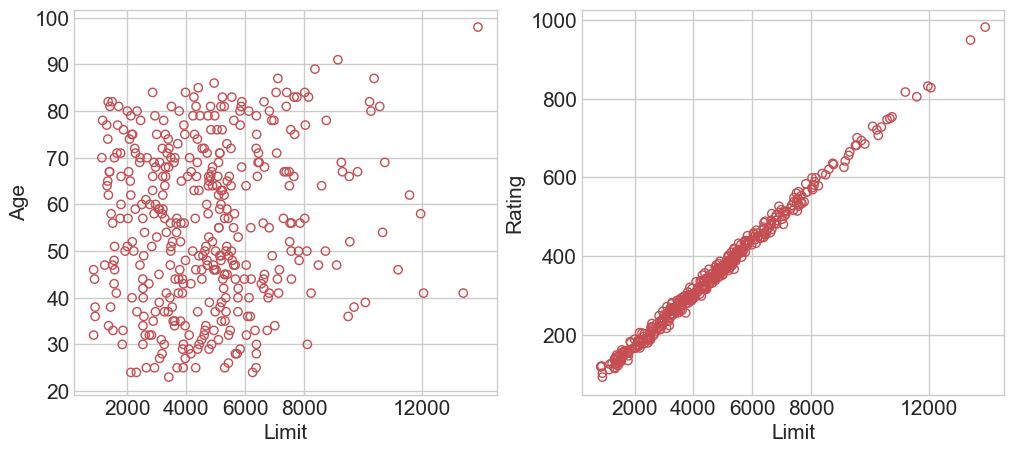

In [47]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,5))

# Left plot
ax1.scatter(credit.Limit, credit.Age, facecolor='None', edgecolor='r')
ax1.set_ylabel('Age', size=15)
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)

# Right plot
ax2.scatter(credit.Limit, credit.Rating, facecolor='None', edgecolor='r')
ax2.set_ylabel('Rating', size=15)
ax2.tick_params(axis='x', labelsize=15)
ax2.tick_params(axis='y', labelsize=15)

for ax in fig.axes:
    ax.set_xlabel('Limit', size=15)
    ax.set_xticks([2000,4000,6000,8000,12000])

Let's examine what happens when we fit two linear regression models. Both will use balance as the dependent variable. Our first model will use age and limit as the predictors, while the second will use rating and limit.

In [48]:
est1 = smf.ols('Balance ~ Age + Limit', credit).fit()
est2 = smf.ols('Balance ~ Rating + Limit', credit).fit()

In [49]:
est1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Balance   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     595.0
Date:                Fri, 10 Apr 2026   Prob (F-statistic):          3.52e-120
Time:                        13:56:25   Log-Likelihood:                -2742.2
No. Observations:                 400   AIC:                             5490.
Df Residuals:                     397   BIC:                             5502.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -173.4109     43.828     -3.957      0.000    -259.576     -87.246
Age           -2.2915      0.672     -3.407      0.001      -3.614      -0.969
Limit          0.1734      0.005     34.496      0.000       0.163       0.183
==============================================================================
Omnibus:                       19.180   Durbin-Watson:                   1.951
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               27.162
Skew:                           0.382   Prob(JB):                     1.26e-06
Kurtosis:                       4.022   Cond. No.                     2.00e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large,  2e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [50]:
est2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Balance   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     582.8
Date:                Fri, 10 Apr 2026   Prob (F-statistic):          7.57e-119
Time:                        13:56:25   Log-Likelihood:                -2745.3
No. Observations:                 400   AIC:                             5497.
Df Residuals:                     397   BIC:                             5509.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -377.5368     45.254     -8.343      0.000    -466.505    -288.569
Rating         2.2017      0.952      2.312      0.021       0.330       4.074
Limit          0.0245      0.064      0.384      0.701      -0.101       0.150
==============================================================================
Omnibus:                       23.153   Durbin-Watson:                   1.964
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               38.187
Skew:                           0.394   Prob(JB):                     5.10e-09
Kurtosis:                       4.293   Cond. No.                     2.06e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.06e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Notice that limit is statiscially significant in the first model, but is not in the second model. Also, the model notes indicate the condition number is large, which could indicate multicollinearity or other problems. The math behind the condition number is beyond the scope of this course, but it's useful to know that the model may tell us when there's an issue.

The next thing we can do is plot the level curves of the RSS against the coefficients, like we did in our first example. This is shown in Figure 3.15. We'll use the coeffidients of the two variables, and ignore $\beta_0$ (intercept) for now.

In [51]:
y = credit.Balance

# Regression for left plot
X = credit[['Age', 'Limit']]
regr1 = skl_lm.LinearRegression()
regr1.fit(scale(X.astype('float'), with_std=False), y)

# Regression for right plot
X2 = credit[['Rating', 'Limit']]
regr2 = skl_lm.LinearRegression()
regr2.fit(scale(X2.astype('float'), with_std=False), y)

LinearRegression()

LinearRegression()

In [52]:
# Create grid coordinates for plotting
B_Age = np.linspace(regr1.coef_[0]-3, regr1.coef_[0]+3, 100)
B_Limit = np.linspace(regr1.coef_[1]-0.02, regr1.coef_[1]+0.02, 100)

B_Rating = np.linspace(regr2.coef_[0]-3, regr2.coef_[0]+3, 100)
B_Limit2 = np.linspace(regr2.coef_[1]-0.2, regr2.coef_[1]+0.2, 100)

X1, Y1 = np.meshgrid(B_Limit, B_Age, indexing='xy')
X2, Y2 = np.meshgrid(B_Limit2, B_Rating, indexing='xy')
Z1 = np.zeros((B_Age.size,B_Limit.size))
Z2 = np.zeros((B_Rating.size,B_Limit2.size))

Limit_scaled = scale(credit.Limit.astype('float'), with_std=False)
Age_scaled = scale(credit.Age.astype('float'), with_std=False)
Rating_scaled = scale(credit.Rating.astype('float'), with_std=False)

# Calculate Z-values (RSS) based on grid of coefficients
for (i,j),v in np.ndenumerate(Z1):
    Z1[i,j] =((y - (regr1.intercept_ + X1[i,j]*Limit_scaled +
                    Y1[i,j]*Age_scaled))**2).sum()/1000000

for (i,j),v in np.ndenumerate(Z2):
    Z2[i,j] =((y - (regr2.intercept_ + X2[i,j]*Limit_scaled +
                    Y2[i,j]*Rating_scaled))**2).sum()/1000000

Text(0.5, 0.98, 'RSS - Regression coefficients')

<a list of 3 text.Text objects>

Text(0, 0.5, '$\\beta_{Age}$')

<a list of 2 text.Text objects>

Text(0, 0.5, '$\\beta_{Rating}$')

Text(0.5, 0, '$\\beta_{Limit}$')

Text(0.5, 0, '$\\beta_{Limit}$')

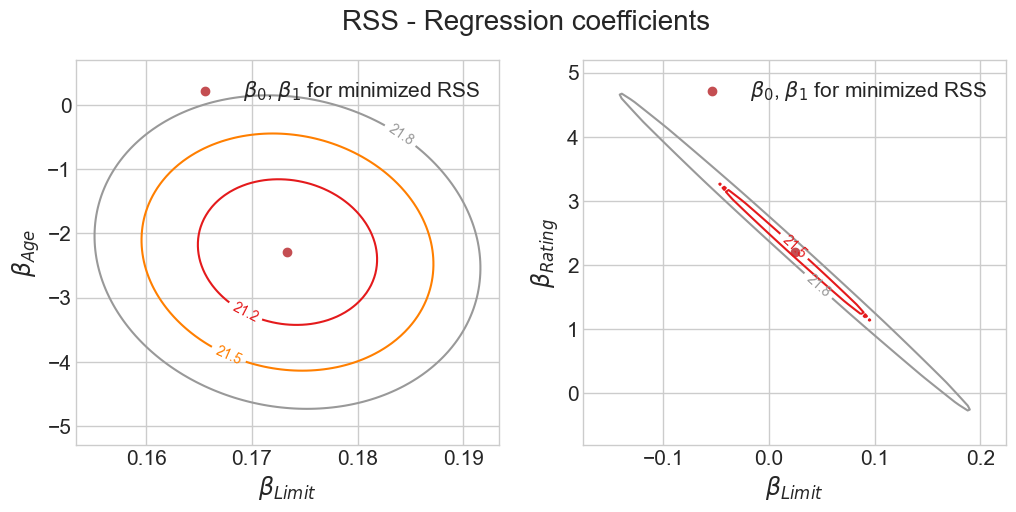

In [53]:
fig = plt.figure(figsize=(12,5))
fig.suptitle('RSS - Regression coefficients', fontsize=20)

ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

min_RSS = r'$\beta_0$, $\beta_1$ for minimized RSS'

# Left plot
CS = ax1.contour(X1, Y1, Z1, cmap=plt.cm.Set1, levels=[21.25, 21.5, 21.8])
ax1.scatter(regr1.coef_[1], regr1.coef_[0], c='r', label=min_RSS)
ax1.clabel(CS, inline=True, fontsize=10, fmt='%1.1f')
ax1.set_ylabel(r'$\beta_{Age}$', fontsize=17)

# Right plot
CS = ax2.contour(X2, Y2, Z2, cmap=plt.cm.Set1, levels=[21.5, 21.8])
ax2.scatter(regr2.coef_[1], regr2.coef_[0], c='r', label=min_RSS)
ax2.clabel(CS, inline=True, fontsize=10, fmt='%1.1f')
ax2.set_ylabel(r'$\beta_{Rating}$', fontsize=17)
ax2.set_xticks([-0.1, 0, 0.1, 0.2])

for ax in fig.axes:
    ax.set_xlabel(r'$\beta_{Limit}$', fontsize=17)
    ax.legend(fontsize=15)
    ax.tick_params(axis='x', labelsize=15)
    ax.tick_params(axis='y', labelsize=15)

Notice on the left that a clear point exists for the minimum RSS. On the right, because of the collinearity, there are several pairs ($\beta_{Limit}$, $\beta_{Rating}$) that have similar RSS values. a slight change in the data could lead to dramatically different coefficients.

A test we have for multicollinearity is the Variance Inflation Factor, or VIF. Values close to 1 indicate no collinearity, while larger values indicate a problem. As a rule of thumb, a value larger than 5 or 10 indicates enough collinearity to cause an issue.

In [54]:
est_Age = smf.ols('Age ~ Rating + Limit', credit).fit()
est_Rating = smf.ols('Rating ~ Age + Limit', credit).fit()
est_Limit = smf.ols('Limit ~ Age + Rating', credit).fit()

print(1/(1-est_Age.rsquared))
print(1/(1-est_Rating.rsquared))
print(1/(1-est_Limit.rsquared))

1.011384686068133
160.66830095856935
160.59287978597942


Based on the VIF values, there certainly is a collinearity problem caused by the presence of Rating or Limit. We could combine them into a single variable or simply drop one. For example, we could simply drop Rating, and use regression on just Age and Limit.

In [55]:
est_Age = smf.ols('Age ~ Limit', credit).fit()
est_Limit = smf.ols('Limit ~ Age', credit).fit()

print(1/(1-est_Age.rsquared))
print(1/(1-est_Limit.rsquared))

1.0102830373035872
1.0102830373035872


In tihs case, our VIF values drop to nearly 1.

In [56]:
est1 = smf.ols('Balance ~ Age + Limit + Rating', credit).fit()
est2 = smf.ols('Balance ~ Age + Limit', credit).fit()

In [57]:
est1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Balance   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     403.7
Date:                Fri, 10 Apr 2026   Prob (F-statistic):          4.84e-120
Time:                        13:56:27   Log-Likelihood:                -2739.2
No. Observations:                 400   AIC:                             5486.
Df Residuals:                     396   BIC:                             5502.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -259.5175     55.882     -4.644      0.000    -369.380    -149.655
Age           -2.3458      0.669     -3.508      0.001      -3.660      -1.031
Limit          0.0190      0.063      0.302      0.763      -0.105       0.143
Rating         2.3105      0.940      2.459      0.014       0.463       4.158
==============================================================================
Omnibus:                       20.764   Durbin-Watson:                   1.962
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               33.727
Skew:                           0.360   Prob(JB):                     4.74e-08
Kurtosis:                       4.227   Cond. No.                     2.58e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.58e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [58]:
est2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Balance   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     595.0
Date:                Fri, 10 Apr 2026   Prob (F-statistic):          3.52e-120
Time:                        13:56:27   Log-Likelihood:                -2742.2
No. Observations:                 400   AIC:                             5490.
Df Residuals:                     397   BIC:                             5502.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -173.4109     43.828     -3.957      0.000    -259.576     -87.246
Age           -2.2915      0.672     -3.407      0.001      -3.614      -0.969
Limit          0.1734      0.005     34.496      0.000       0.163       0.183
==============================================================================
Omnibus:                       19.180   Durbin-Watson:                   1.951
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               27.162
Skew:                           0.382   Prob(JB):                     1.26e-06
Kurtosis:                       4.022   Cond. No.                     2.00e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large,  2e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

On the other hand, since Limit contains most of the information reflected in Rating, when we drop Rating from the regression, the $R^2$ only falls from 0.754 to 0.75.

## Boston Housing Data

The Boston data set has medv (median hosue value) along with several predictors, including average number of rooms per house, age of house, percent of households with low socioeconomic status, for 506 neighborhoods around Boston. You can see descriptions of the predictors [here](https://search.r-project.org/CRAN/refmans/ExamPAData/html/boston.html).

In [59]:
url4 = 'https://raw.githubusercontent.com/dsahota-applied-data-analysis/data/main/Boston.csv'
boston = pd.read_csv(url4).drop('Unnamed: 0', axis='columns')
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  black    506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [60]:
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


### Simple Linear Regression

First we'll fit a simple linear regression, with medv as the response variable and lstat as the predictor.

In [61]:
est = smf.ols('medv ~ lstat', boston).fit()

In [62]:
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           5.08e-88
Time:                        13:56:27   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     34.5538      0.563     61.415      0.000      33.448      35.659
lstat         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Note that our coefficient here is statistically significant. We also have $R^2$, F-statistic, confidence interals, along with a few other model performance metrics.

<Axes: xlabel='lstat', ylabel='medv'>

(0.0, 40.0)

(-5.0, 52.57597665414039)

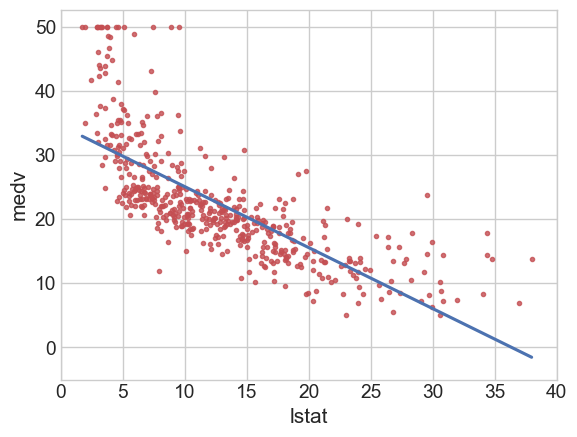

In [63]:
sns.regplot(x = boston.lstat, y = boston.medv, order=1, ci=None, scatter_kws={'color':'r', 's':9})
plt.xlim(0,40)
plt.ylim(ymin=-5)

Based on a quick plot, it does seem like ther is some non-linearity in the data.

<Axes: >

(-5.0, 35.0)

Text(0.5, 0, 'Fitted Values')

(array([-5.,  0.,  5., 10., 15., 20., 25., 30., 35.]),
 [Text(-5.0, 0, '−5'),
  Text(0.0, 0, '0'),
  Text(5.0, 0, '5'),
  Text(10.0, 0, '10'),
  Text(15.0, 0, '15'),
  Text(20.0, 0, '20'),
  Text(25.0, 0, '25'),
  Text(30.0, 0, '30'),
  Text(35.0, 0, '35')])

(array([-20., -15., -10.,  -5.,   0.,   5.,  10.,  15.,  20.,  25.,  30.]),
 [Text(0, -20.0, '−20'),
  Text(0, -15.0, '−15'),
  Text(0, -10.0, '−10'),
  Text(0, -5.0, '−5'),
  Text(0, 0.0, '0'),
  Text(0, 5.0, '5'),
  Text(0, 10.0, '10'),
  Text(0, 15.0, '15'),
  Text(0, 20.0, '20'),
  Text(0, 25.0, '25'),
  Text(0, 30.0, '30')])

Text(0, 0.5, 'Residuals')

Text(0.5, 1.0, 'Residual Plot')

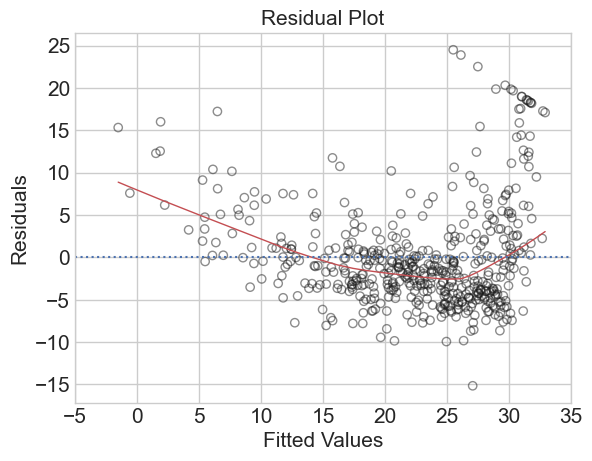

In [64]:
sns.regplot(x = est.fittedvalues, y = est.resid, lowess=True,
            line_kws={'color':'r', 'lw':1},
            scatter_kws={'facecolors':'None', 'edgecolors':'k', 'alpha':0.5})
plt.hlines(0, xmin=-5, xmax=35, linestyles='dotted')
plt.xlim(-5,35)
plt.xlabel('Fitted Values', size=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel('Residuals', size=15)
plt.title('Residual Plot', size=15)
plt.show()

Our plot of residuals confirms there is non-linearity in our data.

### Multiple Linear Regression

We can perform multiple linear regression using lstat and age as predictors.

In [65]:
est = smf.ols('medv ~ lstat + age', boston).fit()

In [66]:
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.551
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     309.0
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           2.98e-88
Time:                        13:56:27   Log-Likelihood:                -1637.5
No. Observations:                 506   AIC:                             3281.
Df Residuals:                     503   BIC:                             3294.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     33.2228      0.731     45.458      0.000      31.787      34.659
lstat         -1.0321      0.048    -21.416      0.000      -1.127      -0.937
age            0.0345      0.012      2.826      0.005       0.011       0.059
==============================================================================
Omnibus:                      124.288   Durbin-Watson:                   0.945
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              244.026
Skew:                           1.362   Prob(JB):                     1.02e-53
Kurtosis:                       5.038   Cond. No.                         201.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

It turns out both lstat and age are statistically significant, but our $R^2$ still isn't very good. We could try a regression on all of the predictors, but instead of typing them all out, we'll use a shorthand.

In [67]:
est = smf.ols('medv ~ ' + " + ".join(boston.columns.difference(['medv'])), boston).fit()

In [68]:
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     108.1
Date:                Fri, 10 Apr 2026   Prob (F-statistic):          6.72e-135
Time:                        13:56:27   Log-Likelihood:                -1498.8
No. Observations:                 506   AIC:                             3026.
Df Residuals:                     492   BIC:                             3085.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     36.4595      5.103      7.144      0.000      26.432      46.487
age            0.0007      0.013      0.052      0.958      -0.025       0.027
black          0.0093      0.003      3.467      0.001       0.004       0.015
chas           2.6867      0.862      3.118      0.002       0.994       4.380
crim          -0.1080      0.033     -3.287      0.001      -0.173      -0.043
dis           -1.4756      0.199     -7.398      0.000      -1.867      -1.084
indus          0.0206      0.061      0.334      0.738      -0.100       0.141
lstat         -0.5248      0.051    -10.347      0.000      -0.624      -0.425
nox          -17.7666      3.820     -4.651      0.000     -25.272     -10.262
ptratio       -0.9527      0.131     -7.283      0.000      -1.210      -0.696
rad            0.3060      0.066      4.613      0.000       0.176       0.436
rm             3.8099      0.418      9.116      0.000       2.989       4.631
tax           -0.0123      0.004     -3.280      0.001      -0.020      -0.005
zn             0.0464      0.014      3.382      0.001       0.019       0.073
==============================================================================
Omnibus:                      178.041   Durbin-Watson:                   1.078
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              783.126
Skew:                           1.521   Prob(JB):                    8.84e-171
Kurtosis:                       8.281   Cond. No.                     1.51e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.51e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The $R^2$ is much better here, and all of the predictors are statistically significant except for age and indus. Let's examine the VIF of each predictor.

In [69]:
predictors = boston.drop('medv', axis='columns')
p = predictors.columns.size
VIFs = np.zeros(p)
for i in range(p):
    e = smf.ols(predictors.columns[i] + ' ~ ' + " + ".join(predictors.columns.difference([predictors.columns[i]])), predictors).fit()
    VIFs[i] = 1/(1-e.rsquared)

In [70]:
pd.DataFrame(VIFs, index = predictors.columns, columns = ['VIF']).rename_axis('predictor')

,VIF
predictor,
crim,1.792192
zn,2.298758
indus,3.991596
chas,1.073995
nox,4.393720
rm,1.933744
age,3.100826
dis,3.955945
rad,7.484496


The VIFs for these predictors are low to moderate, with a possible issue around tax or rad. We could try this regression and exclude age, indus, and tax


In [71]:
est = smf.ols('medv ~ crim + black + chas + rm + dis  + lstat + nox + ptratio + rad + zn', boston).fit()

In [72]:
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.729
Method:                 Least Squares   F-statistic:                     136.7
Date:                Fri, 10 Apr 2026   Prob (F-statistic):          1.84e-135
Time:                        13:56:27   Log-Likelihood:                -1505.0
No. Observations:                 506   AIC:                             3032.
Df Residuals:                     495   BIC:                             3079.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     34.7123      5.103      6.803      0.000      24.687      44.738
crim          -0.1048      0.033     -3.164      0.002      -0.170      -0.040
black          0.0097      0.003      3.591      0.000       0.004       0.015
chas           2.9679      0.861      3.448      0.001       1.277       4.659
rm             3.9771      0.408      9.754      0.000       3.176       4.778
dis           -1.4294      0.187     -7.647      0.000      -1.797      -1.062
lstat         -0.5281      0.048    -11.019      0.000      -0.622      -0.434
nox          -20.3144      3.472     -5.850      0.000     -27.137     -13.492
ptratio       -1.0149      0.129     -7.867      0.000      -1.268      -0.761
rad            0.1288      0.041      3.157      0.002       0.049       0.209
zn             0.0366      0.013      2.731      0.007       0.010       0.063
==============================================================================
Omnibus:                      166.907   Durbin-Watson:                   1.090
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              684.418
Skew:                           1.441   Prob(JB):                    2.40e-149
Kurtosis:                       7.915   Cond. No.                     9.77e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.77e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

This is only slightly worse in $R^2$, dropping from 0.741 to 0.734, but all of our predictors are statistically signifiant now, and we should not have a multicollinearity issue.

In [73]:
new_predictors = boston.drop(['medv', 'age', 'tax', 'indus'], axis='columns')
p = new_predictors.columns.size
VIFs = np.zeros(p)
for i in range(p):
    e = smf.ols(new_predictors.columns[i] + ' ~ ' + " + ".join(new_predictors.columns.difference([new_predictors.columns[i]])), new_predictors).fit()
    VIFs[i] = 1/(1-e.rsquared)

In [74]:
pd.DataFrame(VIFs, index = new_predictors.columns, columns = ['VIF']).rename_axis('predictor')

,VIF
predictor,
crim,1.787963
zn,2.154054
chas,1.052428
nox,3.564036
rm,1.806735
dis,3.410587
rad,2.776775
ptratio,1.717222
black,1.338982


Indeed, removing tax resolved the multicollinearity, so this is a model we should prefer over the first one.

### Interaction Terms

If we want an interaction term, like lstat\*age, we can easily include it. Adding lstat\*age includes lstat and age as predictors as well.

In [75]:
est = smf.ols('medv ~ lstat * age', boston).fit()

In [76]:
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.556
Model:                            OLS   Adj. R-squared:                  0.553
Method:                 Least Squares   F-statistic:                     209.3
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           4.86e-88
Time:                        13:56:27   Log-Likelihood:                -1635.0
No. Observations:                 506   AIC:                             3278.
Df Residuals:                     502   BIC:                             3295.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     36.0885      1.470     24.553      0.000      33.201      38.976
lstat         -1.3921      0.167     -8.313      0.000      -1.721      -1.063
age           -0.0007      0.020     -0.036      0.971      -0.040       0.038
lstat:age      0.0042      0.002      2.244      0.025       0.001       0.008
==============================================================================
Omnibus:                      135.601   Durbin-Watson:                   0.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              296.955
Skew:                           1.417   Prob(JB):                     3.29e-65
Kurtosis:                       5.461   Cond. No.                     6.88e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.88e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Non-linear transformations of the predictors

Powers of variables or other non-linear transformations can be easily included as well, by wrapping the transformation inside I().

In [77]:
est = smf.ols('medv ~ lstat + I(lstat ** 2)', boston).fit()

In [78]:
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.641
Model:                            OLS   Adj. R-squared:                  0.639
Method:                 Least Squares   F-statistic:                     448.5
Date:                Fri, 10 Apr 2026   Prob (F-statistic):          1.56e-112
Time:                        13:56:27   Log-Likelihood:                -1581.3
No. Observations:                 506   AIC:                             3169.
Df Residuals:                     503   BIC:                             3181.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        42.8620      0.872     49.149      0.000      41.149      44.575
lstat            -2.3328      0.124    -18.843      0.000      -2.576      -2.090
I(lstat ** 2)     0.0435      0.004     11.628      0.000       0.036       0.051
==============================================================================
Omnibus:                      107.006   Durbin-Watson:                   0.921
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              228.388
Skew:                           1.128   Prob(JB):                     2.55e-50
Kurtosis:                       5.397   Cond. No.                     1.13e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.13e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""